In [1]:
from functionss_CUDA import *
from preprocessing import *
from integration import *
import pandas as pd
import anndata as ad
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import warnings

import numpy as np
import scanpy as sc
import torch
warnings.filterwarnings('ignore')

# Data Loading

In [2]:
sc_obj=sc.read_visium("./data/Human_DLPFC_scanpy/151673",
                          count_file="151673_filtered_feature_bc_matrix.h5",library_id="151673", load_images= True,
                          source_image_path="./data/Human_DLPFC_scanpy/151673/spatial/")
sc_labels = pd.read_csv('./data/cluster/cluster_labels_151673.csv', index_col=0)
sc_obj.obs['cluster'] = sc_labels['ground_truth'].values
sc_obj = sc_obj[~sc_obj.obs['cluster'].isna()]
st_obj=sc.read_visium("./data/Human_DLPFC_scanpy/151674",
                       count_file='151674_filtered_feature_bc_matrix.h5', library_id="151674", load_images=True,
                       source_image_path="./data/Human_DLPFC_scanpy/151674/spatial/")
st_labels = pd.read_csv('./data/cluster/cluster_labels_151674.csv', index_col=0)
st_obj.obs['cluster'] = st_labels['ground_truth'].values
st_obj = st_obj[~st_obj.obs['cluster'].isna()]

# Preprocessing

In [3]:
sc_adata, st_adata = preprocess(sc_adata=sc_obj, st_adata=st_obj, st_type='spot', n_features=4000, normalize=True,
                                    select_hvg='intersection')

sc_adata: AnnData object with n_obs × n_vars = 3608 × 1769
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'n_genes', 'source'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial', 'spatial_normalized', 'X'
st_adata: AnnData object with n_obs × n_vars = 3635 × 1769
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'n_genes', 'source'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial', 'spatial_normalized', 'X'
Data have been pre-processed!


# Integration

Constructing fuzzy simplicial sets ...
Initializing embedding ...
Optimizing embedding ...
	completed  0  /  180 epochs
	completed  18  /  180 epochs
	completed  36  /  180 epochs
	completed  54  /  180 epochs
	completed  72  /  180 epochs
	completed  90  /  180 epochs
	completed  108  /  180 epochs
	completed  126  /  180 epochs
	completed  144  /  180 epochs
	completed  162  /  180 epochs


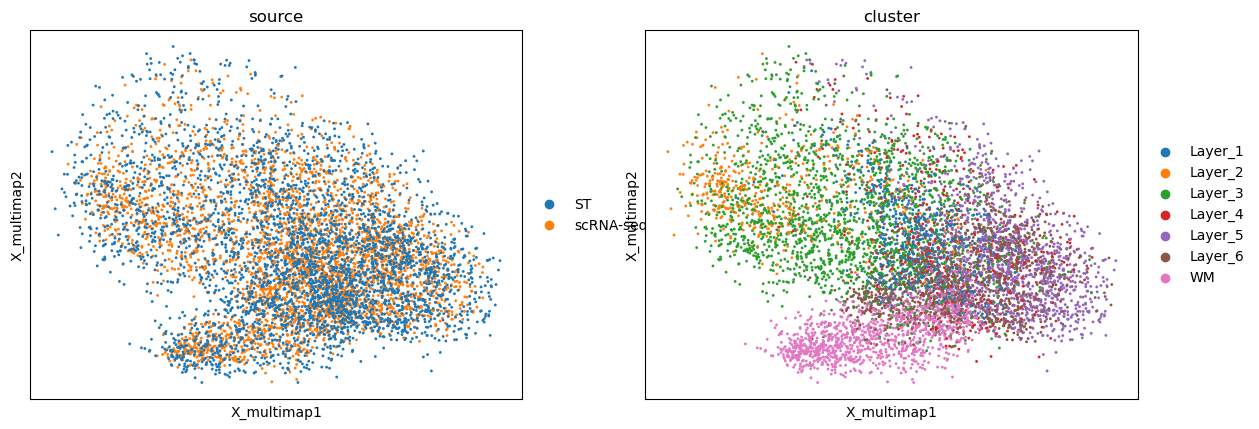

In [38]:
adata = Integration([sc_adata, st_adata], ['X', 'X'], seed=2024, n_epochs=180,n_comps=20,
                    n_neighbors=50,n_components=32,local_connectivity=30.0,spread=1.0,min_dist=0.5)

sc.pl.embedding(adata, 'X_multimap', color=['source','cluster'])

# Spatial Prediction

In [40]:
st_embedding = ad.AnnData(adata.uns['st_embedding'])
sc_embedding = ad.AnnData(adata.uns['sc_embedding'])
st_embedding = torch.tensor(st_embedding.X)
sc_embedding = torch.tensor(sc_embedding.X)
st_location = pd.DataFrame(st_adata.obsm['spatial'], columns=['x', 'y'])

In [41]:
trained_model = Fit_cord(data_train=st_embedding, out_features=2, location_data=st_location,
                                         hidden_dims=[512,256,128,64,32],
                                         num_epochs=500, batch_size=32,
                                         number_error_try=35, initial_learning_rate=0.001,seednum=2024,dropout=0.3,
                                         weight_decay=1e-6,device="cuda:0")

100%|██████████| 114/114 [00:00<00:00, 914.42it/s]


Epoch 1, Learning Rate: 0.001, Loss: 3796440258.0


100%|██████████| 114/114 [00:00<00:00, 904.39it/s]


Epoch 2, Learning Rate: 0.001, Loss: 3240502588.0


100%|██████████| 114/114 [00:00<00:00, 910.17it/s]


...

Epoch 498, Learning Rate: 0.00025, Loss: 144475510.625


100%|██████████| 114/114 [00:00<00:00, 930.01it/s]


Epoch 499, Learning Rate: 0.00025, Loss: 144770014.125


100%|██████████| 114/114 [00:00<00:00, 889.90it/s]

Epoch 500, Learning Rate: 0.00025, Loss: 147038343.375


In [42]:
p_coord= Predict_cord(data_test=sc_embedding,model = trained_model,location_data=None)
sc_adata.obsm['spatial_pred']=p_coord

In [43]:
x = sc_adata.obsm['spatial'].astype(np.float32)
pcc = pearson_corr(torch.tensor(x),torch.tensor(p_coord))
print("PCC:",pcc)

mae = np.mean(np.abs(p_coord-x))
print(f"MAE: {mae}")

cal_dist_ = cal_dist(x, normalize=True)
cal_dist_p = cal_dist(p_coord, normalize=True)
pcc_pair = pearson_corr(torch.tensor(cal_dist_),torch.tensor(cal_dist_p))
print("pcc of pair distance",pcc_pair)

PCC: tensor(0.8252, dtype=torch.float64)
MAE: 961.4063187829671


100%|██████████| 3608/3608 [00:06<00:00, 573.74it/s] 


pcc of pair distance tensor(0.6962, dtype=torch.float64)


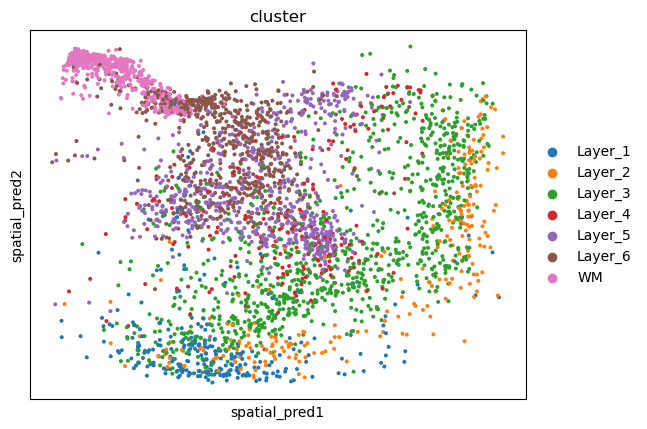

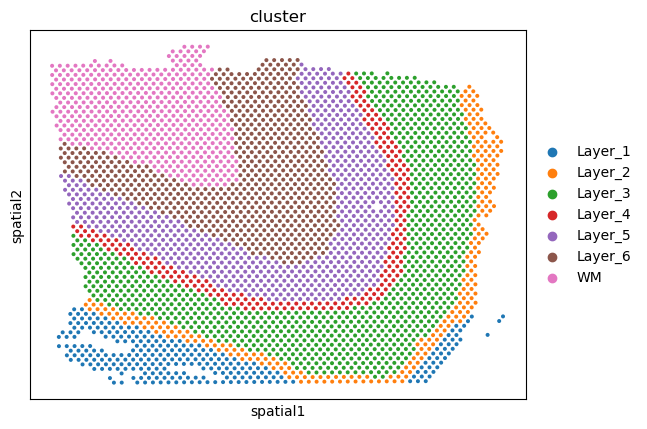

In [44]:
sc.pl.embedding(sc_adata, basis='spatial_pred', color="cluster")
sc.pl.embedding(sc_adata,basis ='spatial',color = 'cluster')